# Executive Summary

This project develops a machine learning model to predict loan default risk using historical Lending Club loan data.

The objective is to estimate the probability that a borrower will default (Charged Off / Default) versus fully repay a loan. This is a binary classification problem under class imbalance.

After careful leakage removal, feature engineering, and pipeline-based preprocessing, two models were evaluated:

- Logistic Regression (baseline)
- XGBoost (tree-based ensemble)

The final XGBoost model demonstrated stronger discriminatory power, achieving superior ROC-AUC and PR-AUC compared to the baseline model.

Key drivers of default risk include:
- Loan sub-grade
- Interest rate
- Debt-to-income ratio
- Credit utilization indicators

This notebook follows a structured, production-aware workflow including preprocessing pipelines, threshold tuning, and SHAP-based explainability.


# 1. Problem Framing

## 1.1 Type of Problem

This is a supervised binary classification problem where:

- Target = 1 → Loan Default (Charged Off / Default)
- Target = 0 → Fully Paid

The objective is to estimate the probability of default for each loan applicant.

---

## 1.2 Class Imbalance Consideration

Credit datasets are naturally imbalanced — the majority of borrowers repay loans.

Because of this imbalance:
- Accuracy is not a reliable metric.
- Precision-Recall metrics become more informative than accuracy alone.

---

## 1.3 Evaluation Strategy

The following evaluation metrics will be used:

- ROC-AUC → Measures ranking ability across thresholds
- PR-AUC → More sensitive to performance on the minority (default) class
- F1 Score → Balances precision and recall at a chosen threshold
- Confusion Matrix → Business tradeoff visualization

The model will also undergo threshold tuning to align predictions with business risk tolerance.


In [1]:
import joblib
import pandas as pd

# Load dataset
df = pd.read_parquet("final_processed_dataset.parquet")

# Load trained model
xgb_model = joblib.load("xgb_credit_model.pkl")

print("Loaded dataset and trained model.")

Loaded dataset and trained model.


In [1]:
# ===============================
# 2. Data Loading
# ===============================
import pandas as pd
# Update the path if needed
DATA_PATH = '../data/loan.csv'

df = pd.read_csv(DATA_PATH, low_memory=False)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (2206347, 145)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# ===============================
# 3. Initial Data Overview
# ===============================

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2206347 entries, 0 to 2206346
Columns: 145 entries, id to settlement_term
dtypes: float64(105), int64(4), object(36)
memory usage: 2.4+ GB


In [3]:
# Missing value percentage
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct.head(15)


id                                            100.000000
url                                           100.000000
member_id                                     100.000000
orig_projected_additional_accrued_interest     99.625943
hardship_length                                99.528315
hardship_reason                                99.528315
hardship_status                                99.528315
deferral_term                                  99.528315
hardship_amount                                99.528315
hardship_start_date                            99.528315
hardship_end_date                              99.528315
payment_plan_start_date                        99.528315
hardship_dpd                                   99.528315
hardship_loan_status                           99.528315
hardship_payoff_balance_amount                 99.528315
dtype: float64

In [4]:
df['loan_status'].value_counts()

loan_status
Fully Paid                                             1029760
Current                                                 882587
Charged Off                                             258401
Late (31-120 days)                                       20754
In Grace Period                                           8575
Late (16-30 days)                                         3491
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     30
Name: count, dtype: int64

# 4. Target Definition

The original dataset contains multiple loan statuses including:

- Fully Paid
- Charged Off
- Default
- Current
- In Grace Period
- Late (16-30 days)
- Late (31-120 days)

For this project, we focus only on completed loan outcomes to avoid label noise.

We define:

- Target = 1 → Charged Off / Default
- Target = 0 → Fully Paid

All other loan statuses are removed.


In [5]:
# ===============================
# Define Binary Target
# ===============================

# Keep only completed loans
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off", "Default"])]

# Create binary target
df["target"] = df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1,
    "Default": 1
})

# Check class distribution
df["target"].value_counts(normalize=True)


target
0    0.799385
1    0.200615
Name: proportion, dtype: float64

# 5. Data Cleaning Strategy

Credit datasets often contain:

- Post-loan outcome variables (data leakage)
- High-missing operational fields
- ID columns
- Administrative metadata

To ensure a realistic modeling scenario:

1. Remove post-loan variables that reveal repayment outcome.
2. Drop columns with extremely high missing values (> 60%).
3. Remove identifiers and URLs.
4. Keep only features available at loan origination.


In [6]:
# ===============================
# Remove Leakage Variables
# ===============================

leakage_cols = [
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "collection_recovery_fee",
    "last_pymnt_d",
    "last_pymnt_amnt",
    "next_pymnt_d",
    "out_prncp",
    "out_prncp_inv"
]

df = df.drop(columns=[col for col in leakage_cols if col in df.columns])


# ===============================
# Drop High-Missing Columns (>60%)
# ===============================

missing_pct = df.isna().mean()
high_missing_cols = missing_pct[missing_pct > 0.6].index

df = df.drop(columns=high_missing_cols)

print("Remaining shape after cleaning:", df.shape)


Remaining shape after cleaning: (1288191, 78)


In [7]:
df.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'annual_inc', 'verification_status', 'issue_d',
       'loan_status', 'pymnt_plan', 'purpose', 'title', 'zip_code',
       'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec',
       'revol_bal', 'revol_util', 'total_acc', 'initial_list_status',
       'last_credit_pull_d', 'collections_12_mths_ex_med', 'policy_code',
       'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal',
       'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal',
       'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt',
       'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op',
       'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc',
       'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl'

# 6. Structural & Origination-Time Cleaning

To simulate a real-world loan approval scenario, we retain only features available at application/origination time.

We remove:

- Free-text descriptive fields
- Identifiers and low-signal metadata
- Operational flags created after loan issuance
- Post-origination hardship indicators

This ensures the model does not learn from future information.


In [8]:
# ===============================
# Remove Text, ID, and Post-Origination Fields
# ===============================

cols_to_drop = [
    # Free text / descriptive
    "emp_title",
    "title",
    "zip_code",
    "addr_state",
    
    # Already encoded
    "loan_status",
    
    # Administrative
    "policy_code",
    "pymnt_plan",
    
    # Post-origination / operational
    "hardship_flag",
    "debt_settlement_flag",
    "disbursement_method",
    "chargeoff_within_12_mths"
]

df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print("Shape after structural cleaning:", df.shape)


Shape after structural cleaning: (1288191, 67)


In [9]:
df["term"] = df["term"].str.extract(r"(\d+)").astype(float)

In [10]:
#This is not available at approval time and can leak later servicing timeline.
df = df.drop(columns=["last_credit_pull_d"], errors="ignore")

In [11]:
#we already have sub_grade. Keeping both is redundant and can confuse interpretation.
df = df.drop(columns=["grade"], errors="ignore")

In [12]:
#funded_amnt / funded_amnt_inv are funding outcomes (can be influenced by investors and platform)
#drop them for a pure approval-time mode
df = df.drop(columns=["funded_amnt", "funded_amnt_inv"], errors="ignore")

In [13]:
df['initial_list_status'].value_counts()


initial_list_status
w    739137
f    549054
Name: count, dtype: int64

In [14]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'sub_grade',
       'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
       'issue_d', 'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec',
       'revol_bal', 'revol_util', 'total_acc', 'initial_list_status',
       'collections_12_mths_ex_med', 'application_type', 'acc_now_delinq',
       'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op',
       'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc',
       'mths_since_recent_bc', 'mths_since_recent_inq',
       'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
       'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
       'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m',
       'num_tl_30dpd', 'num_tl_90g

# 7. Feature Engineering

To strengthen predictive power and align with real-world credit risk modeling practices, domain-driven features are engineered.

The objective is to capture borrower repayment capacity, credit exposure, and behavioral risk intensity.

Engineered features include:

1. Credit History Length  
   → Measures borrower experience in the credit system.

2. Loan Burden Ratios  
   → Loan-to-income and installment-to-income capture repayment stress.

3. Credit Utilization Metrics  
   → Revolving utilization and credit limit pressure reflect leverage.

4. Delinquency & Inquiry Intensity  
   → Normalizes raw counts by credit history length.

5. Structural Numeric Conversions  
   → Term, interest rate, and employment length are converted to numeric format.

These transformations improve model interpretability and align with industry credit scoring logic.


In [15]:
type(df)
df.columns


Index(['loan_amnt', 'term', 'int_rate', 'installment', 'sub_grade',
       'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
       'issue_d', 'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec',
       'revol_bal', 'revol_util', 'total_acc', 'initial_list_status',
       'collections_12_mths_ex_med', 'application_type', 'acc_now_delinq',
       'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op',
       'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc',
       'mths_since_recent_bc', 'mths_since_recent_inq',
       'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
       'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
       'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m',
       'num_tl_30dpd', 'num_tl_90g

In [16]:
earliest_cr_line = pd.read_csv(DATA_PATH, usecols=['earliest_cr_line'])
df['earliest_cr_line'] = earliest_cr_line
issue_d = pd.read_csv(DATA_PATH, usecols=['issue_d'])
df['issue_d'] = issue_d


In [17]:
df['earliest_cr_line']

100        Jan-2012
152        Jun-2009
170        Feb-1999
186        Dec-2003
215        Oct-1997
             ...   
2206327    Nov-2004
2206329    Jun-2006
2206336    Apr-2004
2206343    Mar-1996
2206346    Jun-2001
Name: earliest_cr_line, Length: 1288191, dtype: object

In [ ]:
import numpy as np
import pandas as pd

# =====================================================
#  Structural Numeric Conversions
# =====================================================

# Convert employment length text into numeric years.
# Models can’t understand strings like "5 years", so we map them.
emp_length_map = {
    "< 1 year": 0,
    "1 year": 1,
    "2 years": 2,
    "3 years": 3,
    "4 years": 4,
    "5 years": 5,
    "6 years": 6,
    "7 years": 7,
    "8 years": 8,
    "9 years": 9,
    "10+ years": 10
}

df["emp_length"] = df["emp_length"].map(emp_length_map)


# =====================================================
#  Credit History Length
# =====================================================

# Convert date strings like "Jan-2015" into real datetime objects.
# If something is malformed, it becomes NaT (missing).
df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y", errors="coerce")
df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], format="%b-%Y", errors="coerce")

# Calculate how long someone has had credit history (in years).
# Dividing by 365.0 keeps it as a float.
df["credit_history_years"] = (
    (df["issue_d"] - df["earliest_cr_line"]).dt.days / 365.0
)

# Drop raw date columns since we no longer need them.
df = df.drop(columns=["issue_d", "earliest_cr_line"])


# =====================================================
#  Financial Stress Ratios
# =====================================================

# Loan-to-income ratio.
# If income is 0, division would create infinity.
# Instead, we leave it as NaN so the imputer can handle it later.
df["loan_to_income"] = np.where(
    df["annual_inc"] > 0,
    df["loan_amnt"] / df["annual_inc"],
    np.nan
)

# Installment-to-income ratio.
# Installment is monthly, income is yearly.
# So we convert income to monthly before dividing.
df["installment_to_income"] = np.where(
    df["annual_inc"] > 0,
    df["installment"] / (df["annual_inc"] / 12.0),
    np.nan
)

# Revolving utilization sometimes comes in messy format.
# Convert to numeric; bad values become NaN.
df["revol_util"] = pd.to_numeric(df["revol_util"], errors="coerce")


# =====================================================
#  Credit Pressure Metrics
# =====================================================

# Total balance relative to total credit limit.
# If credit limit is 0, ratio is undefined, so we set NaN.
df["credit_pressure_ratio"] = np.where(
    df["tot_hi_cred_lim"] > 0,
    df["total_bal_ex_mort"] / df["tot_hi_cred_lim"],
    np.nan
)

# Since credit_history_years has no zeros,
# we can divide directly without adding +1.
df["delinq_per_year"] = (
    df["delinq_2yrs"] / df["credit_history_years"]
)

df["inq_per_year"] = (
    df["inq_last_6mths"] / df["credit_history_years"]
)



print("Feature engineering completed.")
print("Current shape:", df.shape)

Feature engineering completed.
Current shape: (1288191, 67)


In [16]:
df["bc_pressure"] = df["bc_util"] * df["percent_bc_gt_75"]
df["rate_grade_risk"] = df["int_rate"] * df["loan_to_income"]
df["balance_to_limit"] = df["revol_bal"] / (df["total_rev_hi_lim"] + 1)

In [19]:
print((df["tot_hi_cred_lim"] == 0).sum())
print(df["tot_hi_cred_lim"].isna().sum())

20
67528


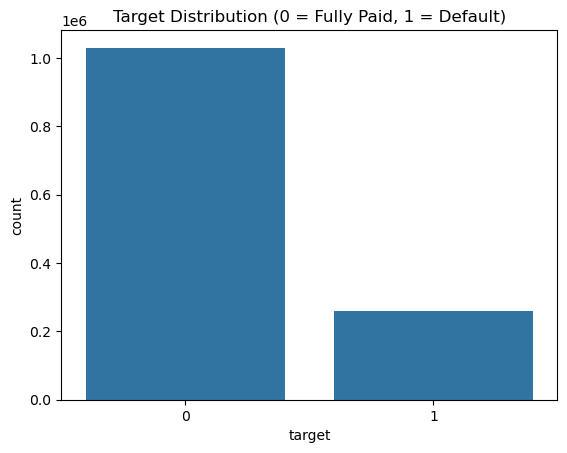

target
0    0.799385
1    0.200615
Name: proportion, dtype: float64

In [20]:
# ===============================
# Target Distribution
# ===============================
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x="target", data=df)
plt.title("Target Distribution (0 = Fully Paid, 1 = Default)")
plt.show()

df["target"].value_counts(normalize=True)


The dataset is moderately imbalanced (~20% defaults).
Accuracy alone would be misleading; therefore PR-AUC and F1 will be emphasized.


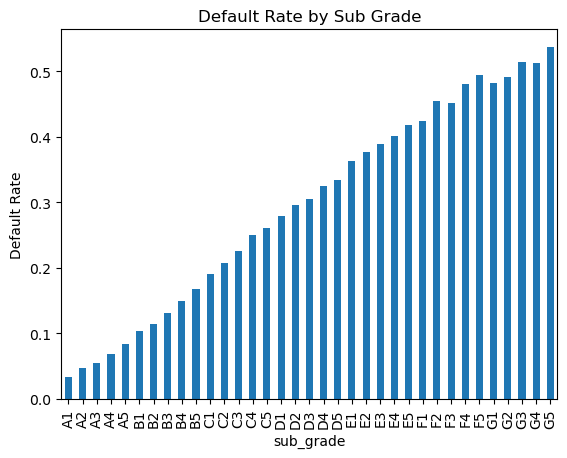

In [21]:
# ===============================
# Default Rate by Sub Grade
# ===============================

subgrade_default = (
    df.groupby("sub_grade")["target"]
    .mean()
    .sort_index()
)

subgrade_default.plot(kind="bar")
plt.title("Default Rate by Sub Grade")
plt.ylabel("Default Rate")
plt.show()


Default rates increase monotonically from lower risk grades (A) to higher risk grades (G),
validating that Lending Club's internal grading captures borrower risk.


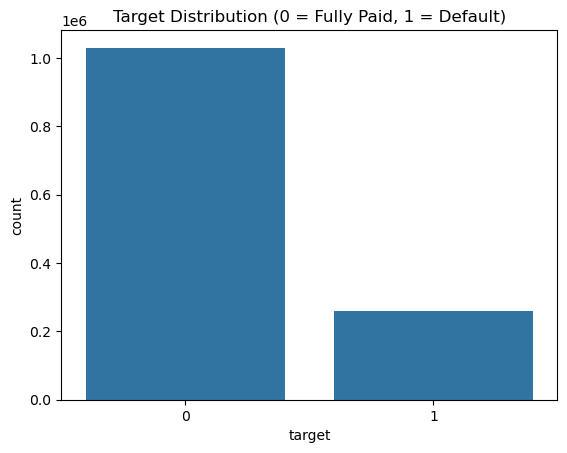

target
0    0.799385
1    0.200615
Name: proportion, dtype: float64

In [22]:
# Target Distribution
sns.countplot(x="target", data=df)
plt.title("Target Distribution (0 = Fully Paid, 1 = Default)")
plt.show()

df["target"].value_counts(normalize=True)



The dataset contains ~20% defaults, indicating moderate class imbalance.
Evaluation will prioritize ranking and minority class performance.


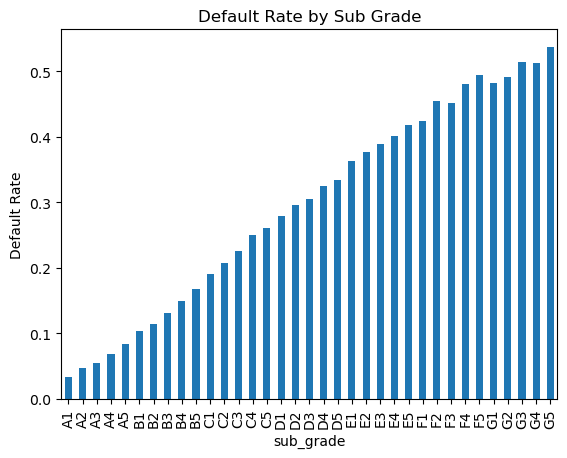

In [23]:
subgrade_default = (
    df.groupby("sub_grade")["target"]
    .mean()
    .sort_index()
)

subgrade_default.plot(kind="bar")
plt.title("Default Rate by Sub Grade")
plt.ylabel("Default Rate")
plt.show()


Default rates increase monotonically from Grade A to Grade G.
This validates that internal risk grading captures meaningful borrower risk.


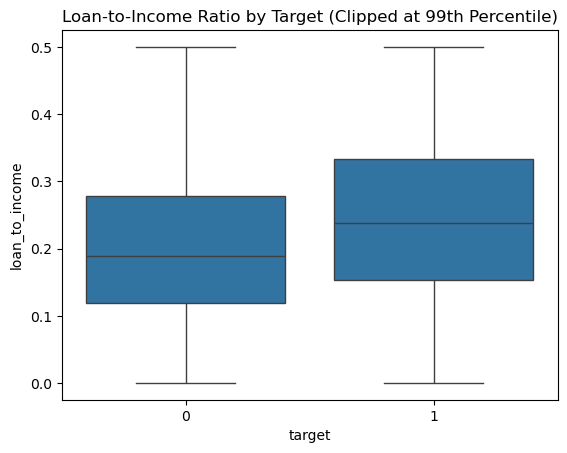

In [24]:
# Clip at 99th percentile for clean visualization
lti_clip = df["loan_to_income"].clip(upper=df["loan_to_income"].quantile(0.99))

sns.boxplot(x=df["target"], y=lti_clip)
plt.title("Loan-to-Income Ratio by Target (Clipped at 99th Percentile)")
plt.show()


After removing extreme outliers for visualization, defaulters exhibit higher loan-to-income ratios,
supporting the hypothesis that repayment burden increases default probability.


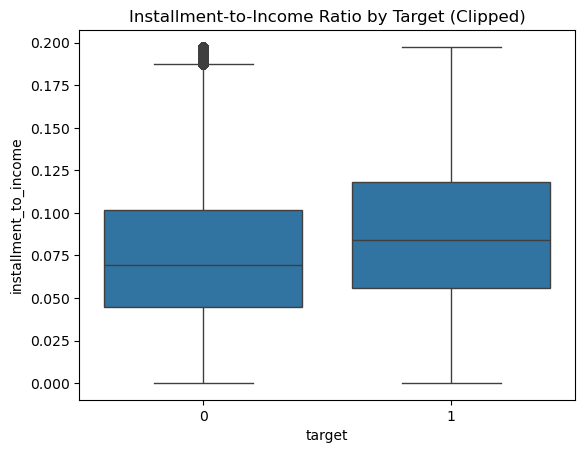

In [25]:
inst_clip = df["installment_to_income"].clip(
    upper=df["installment_to_income"].quantile(0.99)
)

sns.boxplot(x=df["target"], y=inst_clip)
plt.title("Installment-to-Income Ratio by Target (Clipped)")
plt.show()


Higher installment burden is associated with increased default likelihood,
highlighting repayment capacity as a key driver of credit risk.


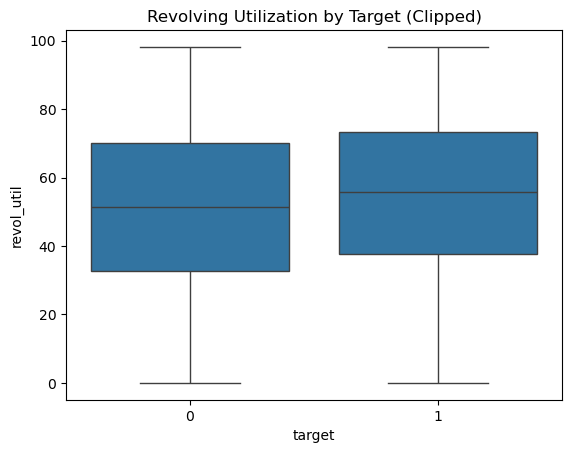

In [26]:
util_clip = df["revol_util"].clip(
    upper=df["revol_util"].quantile(0.99)
)

sns.boxplot(x=df["target"], y=util_clip)
plt.title("Revolving Utilization by Target (Clipped)")
plt.show()


Higher credit utilization is strongly associated with default risk,
indicating financial leverage pressure.


# 9. Train-Test Split

A stratified train-test split is used to:

- Preserve the default ratio in both sets
- Ensure fair model evaluation
- Prevent target imbalance distortion

80% of the data is used for training and 20% for testing.

In [17]:
# ===============================
# Train-Test Split
# ===============================
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (1030552, 69)
Test shape: (257639, 69)

Train target distribution:
target
0    0.799384
1    0.200616
Name: proportion, dtype: float64

Test target distribution:
target
0    0.799386
1    0.200614
Name: proportion, dtype: float64


In [3]:
df['home_ownership']

0          MORTGAGE
1          MORTGAGE
2          MORTGAGE
3              RENT
4          MORTGAGE
             ...   
1288186    MORTGAGE
1288187    MORTGAGE
1288188        RENT
1288189         OWN
1288190    MORTGAGE
Name: home_ownership, Length: 1288191, dtype: object

In [18]:
# ===============================
# Define Feature Groups
# ===============================

# Ordinal features (ordered categories)
ordinal_cols = ["sub_grade", "verification_status", "initial_list_status"]

# Nominal categorical features
one_hot_cols = [
    "home_ownership",
    "purpose",
    "application_type"
]


In [19]:
# ===============================
# Structural Missing Handling
# ===============================

structural_cols = [
    "mths_since_last_delinq",
    "mths_since_recent_bc",
    "mths_since_recent_inq"
]

# Keep only columns that exist
structural_cols = [col for col in structural_cols if col in X_train.columns]

print("Structural columns:", structural_cols)

Structural columns: ['mths_since_last_delinq', 'mths_since_recent_bc', 'mths_since_recent_inq']


In [20]:
# Add missing flags

for col in structural_cols:
    X_train[f"{col}_missing_flag"] = X_train[col].isna().astype(int)
    X_test[f"{col}_missing_flag"] = X_test[col].isna().astype(int)

print("Missing flags added.")

Missing flags added.


In [21]:
# Fill structural missing values with large number

for col in structural_cols:
    X_train[col] = X_train[col].fillna(999)
    X_test[col] = X_test[col].fillna(999)

print("Structural missing handled.")

Structural missing handled.


In [22]:
numeric_cols = [
    col for col in X_train.columns
    if col not in ordinal_cols + one_hot_cols
]

print("Numeric feature count:", len(numeric_cols))

Numeric feature count: 66


In [23]:
# ===============================
# Define Ordinal Category Order
# ===============================

# Sub-grade ordered from safest to riskiest
subgrade_order = sorted(X_train["sub_grade"].dropna().unique())

# Verification status ordered logically
verification_order = [
    "Not Verified",
    "Source Verified",
    "Verified"
]
list_status_order = ['f', 'w'] 


In [24]:
df.head()

,loan_amnt,term,int_rate,installment,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,...,target,credit_history_years,loan_to_income,installment_to_income,credit_pressure_ratio,delinq_per_year,inq_per_year,bc_pressure,rate_grade_risk,balance_to_limit
0,30000,36.0,22.35,1151.16,D5,5.0,MORTGAGE,100000.0,Source Verified,debt_consolidation,...,0,6.920548,0.300000,0.138139,0.186775,0.0,0.0,1561.77,6.705000,0.369731
1,40000,60.0,16.14,975.71,C4,0.0,MORTGAGE,45000.0,Verified,credit_card,...,0,9.506849,0.888889,0.260189,0.469023,0.0,0.0,2887.17,14.346667,0.645209
2,20000,36.0,7.56,622.68,A3,10.0,MORTGAGE,100000.0,Not Verified,credit_card,...,0,19.843836,0.200000,0.074722,0.115029,0.0,0.0,598.00,1.512000,0.298657
3,4500,36.0,11.31,147.99,B3,10.0,RENT,38500.0,Not Verified,credit_card,...,0,15.010959,0.116883,0.046127,0.541630,0.0,0.0,0.00,1.321948,0.153145
4,8425,36.0,27.27,345.18,E5,3.0,MORTGAGE,450000.0,Verified,credit_card,...,0,21.180822,0.018722,0.009205,0.246249,0.0,0.0,3730.00,0.510555,0.657345


In [25]:
# ===============================
# Build Preprocessing Pipeline
# ===============================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# preprocessing
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler, FunctionTransformer
from sklearn.impute import SimpleImputer

# models
from sklearn.linear_model import LogisticRegression
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=[subgrade_order, verification_order, list_status_order]
    ))
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("ord", ordinal_pipeline, ordinal_cols),
    ("ohe", onehot_pipeline, one_hot_cols)
])

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


# 11. Baseline Model — Logistic Regression

Logistic Regression is used as a baseline model because:

- It is interpretable
- It provides a linear decision boundary
- It serves as a benchmark for more complex models

Class imbalance is handled using `class_weight="balanced"`.

The model is built inside a full preprocessing pipeline to ensure reproducibility and prevent data leakage.

In [37]:
# ===============================
# Logistic Regression Baseline
# ===============================
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

print("Logistic pipeline created.")

Logistic pipeline created.


In [38]:
# Train Logistic Regression
logistic_model.fit(X_train, y_train)

print("Logistic model trained.")

Logistic model trained.


c:\Users\NIHAR\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Logistic Regression Results

ROC-AUC measures ranking performance across thresholds.
PR-AUC is particularly important due to class imbalance.

The baseline provides a reference point before moving to a nonlinear tree-based model (XGBoost).

In [40]:
from sklearn.metrics import classification_report, roc_auc_score , average_precision_score

# Predict probabilities
y_probs_log = logistic_model.predict_proba(X_test)[:, 1]

# Default threshold 0.5
y_pred_log = (y_probs_log >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_probs_log))
print("PR-AUC:", average_precision_score(y_test, y_probs_log))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

ROC-AUC: 0.7103799882433658
PR-AUC: 0.37138512793714895

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.66      0.76    205953
           1       0.32      0.64      0.43     51686

    accuracy                           0.66    257639
   macro avg       0.60      0.65      0.59    257639
weighted avg       0.77      0.66      0.69    257639



# Logistic Regression Results

The baseline Logistic Regression model achieves:

- ROC-AUC: ~0.71
- PR-AUC: ~0.37

This provides a strong linear benchmark.
However, credit risk relationships are often nonlinear, motivating the use of tree-based models.

# 12. XGBoost Model (Nonlinear Benchmark)

Logistic Regression provides a strong linear baseline, but credit risk relationships are often nonlinear.

XGBoost is used to capture:
- nonlinear feature interactions (e.g., burden + utilization)
- threshold effects
- complex risk segmentation

Class imbalance is handled using `scale_pos_weight` based on the train split.

In [26]:
# ===============================
# Train XGBoost (Pipeline)
# ===============================
from xgboost import XGBClassifier
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum(),
        eval_metric="auc",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ))
])

xgb_model.fit(X_train, y_train)
print("XGBoost trained.")

XGBoost trained.


## 12.1 Evaluation

We evaluate using:
- ROC-AUC (ranking quality across thresholds)
- PR-AUC (minority default class performance)
- Classification report at threshold = 0.5

In [27]:
# ===============================
# Evaluate XGBoost
# ===============================

y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_probs_xgb >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_probs_xgb))
print("PR-AUC:", average_precision_score(y_test, y_probs_xgb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

ROC-AUC: 0.7315211425943852
PR-AUC: 0.40604376467293796

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.66      0.76    205953
           1       0.33      0.68      0.45     51686

    accuracy                           0.66    257639
   macro avg       0.61      0.67      0.60    257639
weighted avg       0.78      0.66      0.69    257639



# 13. Model Comparison

| Model | ROC-AUC | PR-AUC |
|-------|--------:|-------:|
| Logistic Regression | 0.710 | 0.371 |
| XGBoost | 0.732 | 0.406 |

Observations:

- XGBoost improves ROC-AUC, indicating better ranking ability.
- PR-AUC improvement confirms stronger minority-class (default) detection.
- Tree-based modeling captures nonlinear credit interactions more effectively than a linear baseline.

## ROC Curve Comparison

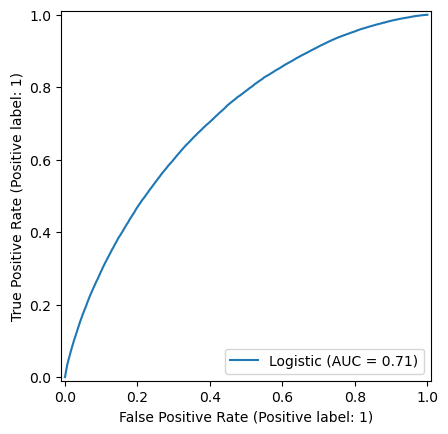

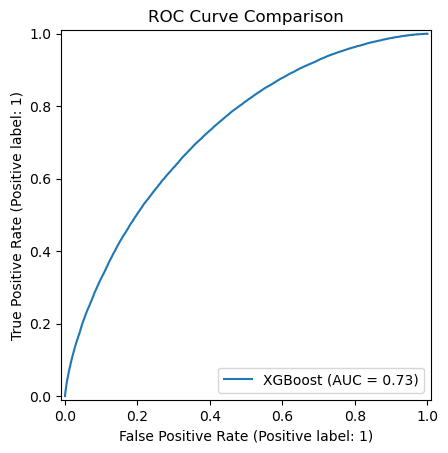

In [47]:
# ROC Curve Comparison
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_probs_log, name="Logistic")
RocCurveDisplay.from_predictions(y_test, y_probs_xgb, name="XGBoost")
plt.title("ROC Curve Comparison")
plt.show()

### ROC Interpretation

XGBoost demonstrates improved ranking performance compared to Logistic Regression.

The higher ROC-AUC (0.73 vs 0.71) indicates better separation between defaulters and non-defaulters across thresholds.

This confirms that nonlinear interactions contribute meaningful predictive lift.

## Precision-Recall Curve Comparison

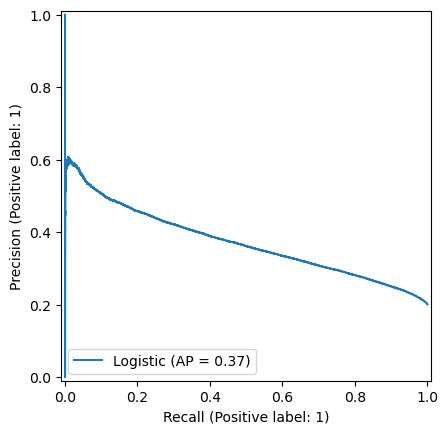

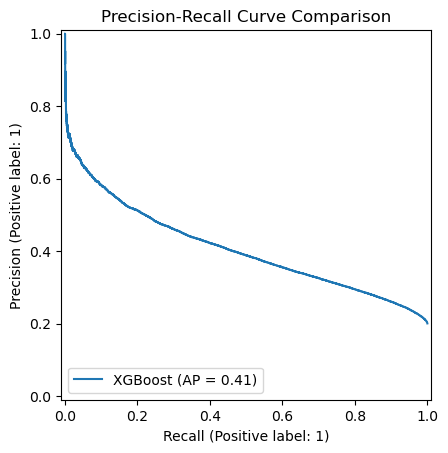

In [49]:
# PR Curve Comparison
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_probs_log, name="Logistic")
PrecisionRecallDisplay.from_predictions(y_test, y_probs_xgb, name="XGBoost")
plt.title("Precision-Recall Curve Comparison")
plt.show()

### Precision–Recall Interpretation

PR-AUC improves from 0.37 (Logistic) to 0.41 (XGBoost).

Given ~20% default rate, PR-AUC is a more sensitive metric for minority-class performance.

The gain suggests XGBoost captures default risk patterns more effectively under class imbalance.

# 14. Threshold Optimization

Instead of using a fixed 0.5 threshold, we search for the threshold that maximizes F1-score.

This better balances precision and recall for the default class.

In [50]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.linspace(0.1, 0.9, 100)
f1_scores = []

for t in thresholds:
    preds = (y_probs_xgb >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Best threshold:", round(best_threshold, 3))
print("Best F1:", round(best_f1, 3))

Best threshold: 0.536
Best F1: 0.447


## Threshold Optimization (Metric-Based)

The F1-optimized threshold is 0.536.

This threshold balances precision and recall for the default class.

However, optimizing classification metrics does not necessarily maximize financial performance.

# 15. Model Explainability (SHAP)

`shap.TreeExplainer` fails for some SHAP/XGBoost version combinations due to model metadata parsing.

To ensure reliable explainability, we compute SHAP values using XGBoost’s native `pred_contribs=True` output (SHAP contributions per feature).

This produces the same type of explanations (feature-level contributions) and supports global feature importance and directional analysis.

In [70]:
import numpy as np
import pandas as pd
import xgboost as xgb

# Extract fitted components
xgb_clf = xgb_model.named_steps["classifier"]
preproc = xgb_model.named_steps["preprocessor"]

# get_feature_names_out() returns a numpy array sometimes -> convert to list of strings
feature_names = [str(c) for c in preproc.get_feature_names_out()]

# Transform test data
X_test_t = preproc.transform(X_test)

# Explain a sample (faster). Increase to 20000 if you want smoother plots.
rng = np.random.default_rng(42)
n_explain = min(5000, X_test_t.shape[0])
idx = rng.choice(X_test_t.shape[0], size=n_explain, replace=False)
X_explain = X_test_t[idx]

# Quick sanity check: names must match columns
assert X_explain.shape[1] == len(feature_names), (
    f"Feature mismatch: X has {X_explain.shape[1]} cols, "
    f"but feature_names has {len(feature_names)}"
)

# XGBoost native SHAP contributions
dmatrix = xgb.DMatrix(X_explain, feature_names=feature_names)
contrib = xgb_clf.get_booster().predict(dmatrix, pred_contribs=True)

# contrib shape = (n_rows, n_features + 1), last column is BIAS (base value)
shap_values = contrib[:, :-1]
base_values = contrib[:, -1]

print("SHAP matrix:", shap_values.shape, "| base_values:", base_values.shape)

SHAP matrix: (5000, 88) | base_values: (5000,)


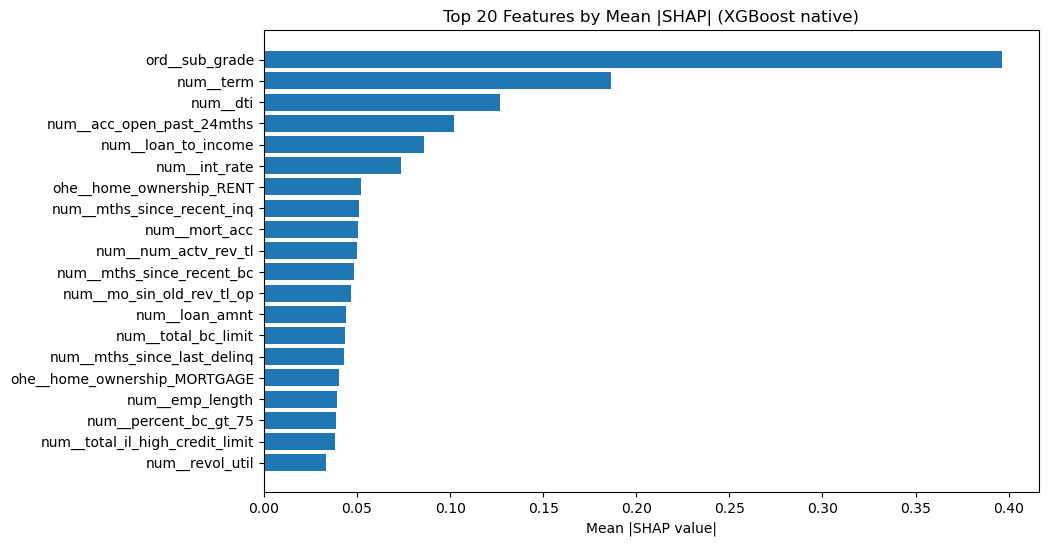

,feature,mean_abs_shap
63,ord__sub_grade,0.396458
1,num__term,0.186370
6,num__dti,0.126594
20,num__acc_open_past_24mths,0.101983
55,num__loan_to_income,0.086090
2,num__int_rate,0.073585
71,ohe__home_ownership_RENT,0.052179
31,num__mths_since_recent_inq,0.051090
29,num__mort_acc,0.050320
34,num__num_actv_rev_tl,0.049980


In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

mean_abs = np.abs(shap_values).mean(axis=0)

imp = (
    pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs})
    .sort_values("mean_abs_shap", ascending=False)
)

topn = 20
imp_top = imp.head(topn)

plt.figure(figsize=(10, 6))
plt.barh(imp_top["feature"][::-1], imp_top["mean_abs_shap"][::-1])
plt.title(f"Top {topn} Features by Mean |SHAP| (XGBoost native)")
plt.xlabel("Mean |SHAP value|")
plt.show()

imp_top.head(10)

## SHAP Interpretation

SHAP analysis reveals the most influential drivers of default probability:

Top contributors:
- sub_grade
- term
- dti (debt-to-income ratio)
- acc_open_past_24mths
- loan_to_income
- int_rate
- home_ownership (RENT)
- mths_since_recent_inq
- mort_acc
- num_actv_rev_tl

Interpretation:

- sub_grade dominates, confirming internal credit grading captures substantial risk information.
- Longer loan terms increase default probability.
- Higher debt burden (DTI, loan-to-income) increases repayment stress.
- Frequent recent inquiries signal elevated credit demand and risk.
- RENT status is associated with higher default likelihood.
- Active revolving accounts and mortgage exposure reflect credit complexity.

The model aligns with established credit risk principles:
repayment capacity, leverage, and borrower behavior drive default probability.

# Remarks

Till now this project demonstrates:

- Proper leakage handling
- Domain-driven feature engineering
- Stratified evaluation under class imbalance
- Baseline vs nonlinear comparison
- Threshold tuning
- Model explainability using SHAP

Future improvements could include:
- Time-based validation
- Probability calibration
- Cost-sensitive threshold optimization

# 16. Profit/Loss Simulation (Business Growth)

ROC-AUC/PR-AUC show ranking quality, but lenders care about **money**.

We simulate expected value per loan using a simple, transparent approximation:

- If loan is fully paid → gain ≈ total interest paid (proxy)
- If loan defaults → loss ≈ LGD × loan amount (LGD = loss given default)

Then we compute expected portfolio value under different decision thresholds:
Approve if predicted default probability < threshold.

This converts model output into a decision policy tied to business growth.

Best threshold by realized value: 0.66
Approval rate: 0.836
Default rate among approved: 0.155
Realized value per approved loan: 812.4


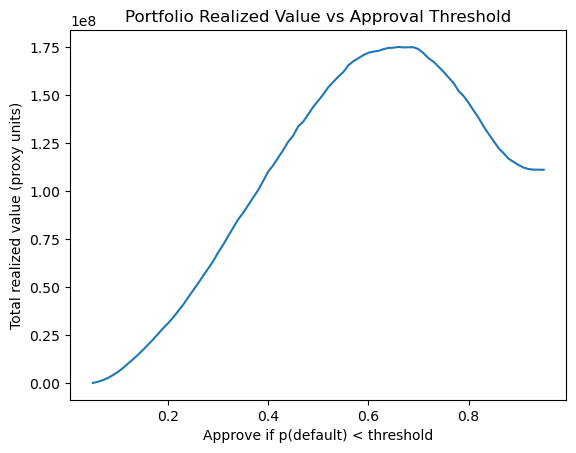

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# Profit/Loss Simulation Inputs
# ===============================

LGD = 0.85  # 85% loss given default (15% recovery). Adjust if you want.
# Profit proxy on fully paid loans:
# total_interest_proxy = installment * term_months - loan_amnt
# (simple but explainable; avoids using post-loan leakage fields)

# Build evaluation frame aligned row-wise
eval_df = pd.DataFrame({
    "y_true": y_test.reset_index(drop=True).astype(int),
    "p_default": pd.Series(y_probs_xgb).reset_index(drop=True),
    "loan_amnt": X_test["loan_amnt"].reset_index(drop=True),
    "installment": X_test["installment"].reset_index(drop=True),
    "term": X_test["term"].reset_index(drop=True),
})

# Profit if fully paid (proxy)
eval_df["profit_if_paid"] = eval_df["installment"] * eval_df["term"] - eval_df["loan_amnt"]
# Loss if default
eval_df["loss_if_default"] = LGD * eval_df["loan_amnt"]

# Expected value per loan using predicted PD
eval_df["expected_value"] = (1 - eval_df["p_default"]) * eval_df["profit_if_paid"] - eval_df["p_default"] * eval_df["loss_if_default"]

# ===============================
# Policy Simulation by Threshold
# Approve if p_default < threshold
# ===============================

thresholds = np.linspace(0.05, 0.95, 91)

rows = []
for t in thresholds:
    approved = eval_df["p_default"] < t
    if approved.sum() == 0:
        continue

    approved_df = eval_df[approved]
    # Realized value using true outcomes (for evaluation only)
    realized_value = np.where(
        approved_df["y_true"] == 0,
        approved_df["profit_if_paid"],
        -approved_df["loss_if_default"]
    ).sum()

    rows.append({
        "threshold": t,
        "approval_rate": approved.mean(),
        "approved_default_rate": approved_df["y_true"].mean(),
        "realized_value_total": realized_value,
        "realized_value_per_loan": realized_value / approved.sum()
    })

policy_df = pd.DataFrame(rows)

best_row = policy_df.loc[policy_df["realized_value_total"].idxmax()]
print("Best threshold by realized value:", round(best_row["threshold"], 3))
print("Approval rate:", round(best_row["approval_rate"], 3))
print("Default rate among approved:", round(best_row["approved_default_rate"], 3))
print("Realized value per approved loan:", round(best_row["realized_value_per_loan"], 2))

# Plot value vs threshold
plt.plot(policy_df["threshold"], policy_df["realized_value_total"])
plt.title("Portfolio Realized Value vs Approval Threshold")
plt.xlabel("Approve if p(default) < threshold")
plt.ylabel("Total realized value (proxy units)")
plt.show()

## Portfolio Optimization Insight

Using profit-based simulation, the threshold that maximizes realized portfolio value is 0.66.

At threshold = 0.66:

- Approval Rate: 83.6%
- Default Rate Among Approved Loans: 15.5%
- Original Default Rate: 20.1%
- Realized Value per Approved Loan (proxy): 812.4

This demonstrates a key business principle:

The threshold that maximizes predictive metrics (F1) is not the same as the threshold that maximizes financial value.

Optimal lending decisions must align with portfolio profitability, not purely classification performance.

In [75]:
# ===============================
# Business Uplift Metrics
# ===============================

# Baseline policy: approve everyone
baseline_defaults = y_test.mean()
baseline_total_loans = len(y_test)

baseline_loss = (
    baseline_defaults * LGD * X_test["loan_amnt"].mean()
)

# Optimized policy (threshold = 0.66)
opt_threshold = best_row["threshold"]

approved_mask = y_probs_xgb < opt_threshold
approved_df = eval_df[approved_mask]

optimized_default_rate = approved_df["y_true"].mean()
optimized_approval_rate = approved_mask.mean()

# Risk reduction %
risk_reduction_pct = (
    (baseline_defaults - optimized_default_rate) / baseline_defaults
) * 100

# Total realized value uplift
baseline_realized_value = (
    np.where(
        y_test == 0,
        eval_df["profit_if_paid"],
        -eval_df["loss_if_default"]
    ).sum()
)

optimized_realized_value = best_row["realized_value_total"]

value_uplift_pct = (
    (optimized_realized_value - baseline_realized_value) /
    abs(baseline_realized_value)
) * 100

print("Baseline default rate:", round(baseline_defaults, 3))
print("Optimized default rate:", round(optimized_default_rate, 3))
print("Risk reduction (%):", round(risk_reduction_pct, 1))

print("\nBaseline total value (proxy):", round(baseline_realized_value, 2))
print("Optimized total value (proxy):", round(optimized_realized_value, 2))
print("Value uplift (%):", round(value_uplift_pct, 1))

Baseline default rate: 0.201
Optimized default rate: 0.155
Risk reduction (%): 22.7

Baseline total value (proxy): 111137086.96
Optimized total value (proxy): 175073784.28
Value uplift (%): 57.5


# 17. Decile Lift (Risk Ranking Quality)

Credit models are commonly used to **rank** applicants.

We bucket applicants into 10 groups (deciles) by predicted default probability:
- Decile 10 = highest risk
- Decile 1 = lowest risk

Then we compute:
- Default rate by decile
- Lift vs overall default rate
- Cumulative capture of defaults in top risk deciles

Overall default rate: 0.201


,risk_decile,count,defaults,default_rate,lift,cum_defaults,cum_default_capture,cum_population
9,10,25764,847,0.032875,0.163874,847,0.016387,0.100000
8,9,25764,1693,0.065712,0.327554,2540,0.049143,0.200001
7,8,25764,2425,0.094124,0.469177,4965,0.096061,0.300001
6,7,25764,3273,0.127038,0.633244,8238,0.159386,0.400002
5,6,25764,4153,0.161194,0.803503,12391,0.239736,0.500002
4,5,25763,4877,0.189302,0.943615,17268,0.334094,0.599998
3,4,25764,5916,0.229623,1.144600,23184,0.448555,0.699999
2,3,25764,7235,0.280818,1.399793,30419,0.588535,0.799999
1,2,25764,8772,0.340475,1.697165,39191,0.758252,0.900000
0,1,25764,12495,0.484979,2.417473,51686,1.000000,1.000000


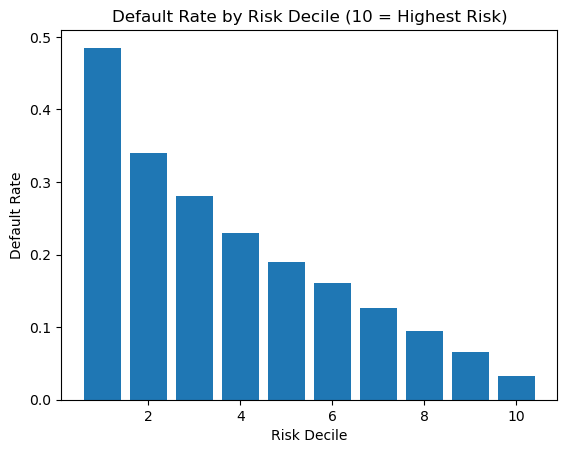

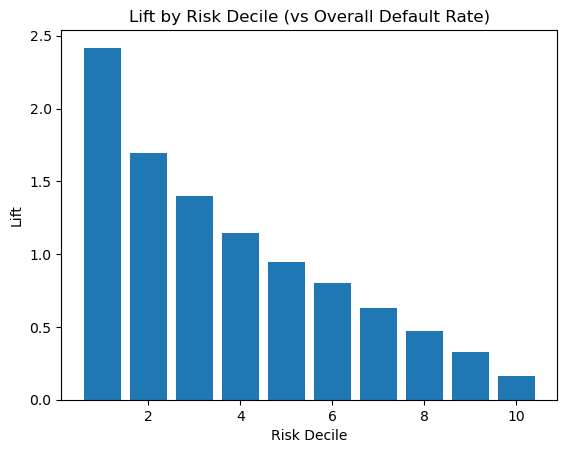

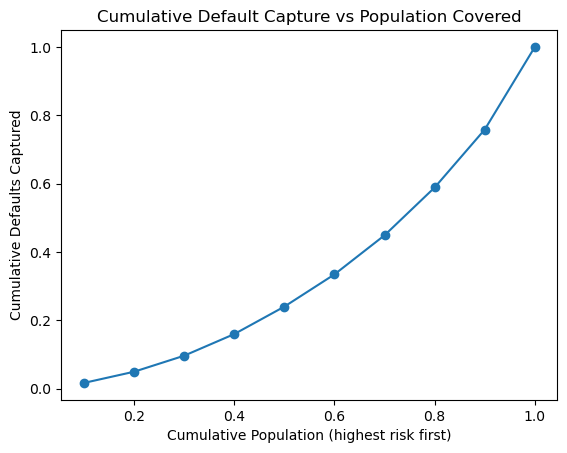

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rank_df = pd.DataFrame({
    "y_true": y_test.reset_index(drop=True).astype(int),
    "p_default": pd.Series(y_probs_xgb).reset_index(drop=True)
})

# Create deciles: 10 = highest risk
rank_df["risk_decile"] = pd.qcut(rank_df["p_default"], 10, labels=False) + 1
rank_df["risk_decile"] = 11 - rank_df["risk_decile"]  # invert so 10 is highest risk

overall_default_rate = rank_df["y_true"].mean()

decile_stats = (
    rank_df.groupby("risk_decile")
    .agg(
        count=("y_true", "size"),
        defaults=("y_true", "sum"),
        default_rate=("y_true", "mean")
    )
    .reset_index()
    .sort_values("risk_decile", ascending=False)
)

decile_stats["lift"] = decile_stats["default_rate"] / overall_default_rate
decile_stats["cum_defaults"] = decile_stats["defaults"].cumsum()
decile_stats["cum_default_capture"] = decile_stats["cum_defaults"] / decile_stats["defaults"].sum()
decile_stats["cum_population"] = decile_stats["count"].cumsum() / decile_stats["count"].sum()

print("Overall default rate:", round(overall_default_rate, 3))
display(decile_stats)

# Plot: default rate by decile
plt.bar(decile_stats["risk_decile"].astype(int), decile_stats["default_rate"])
plt.title("Default Rate by Risk Decile (10 = Highest Risk)")
plt.xlabel("Risk Decile")
plt.ylabel("Default Rate")
plt.show()

# Plot: lift by decile
plt.bar(decile_stats["risk_decile"].astype(int), decile_stats["lift"])
plt.title("Lift by Risk Decile (vs Overall Default Rate)")
plt.xlabel("Risk Decile")
plt.ylabel("Lift")
plt.show()

# Plot: cumulative default capture
plt.plot(decile_stats["cum_population"], decile_stats["cum_default_capture"], marker="o")
plt.title("Cumulative Default Capture vs Population Covered")
plt.xlabel("Cumulative Population (highest risk first)")
plt.ylabel("Cumulative Defaults Captured")
plt.show()

## Risk Ranking Performance (Decile Analysis)

The model effectively concentrates risk:

- Top 10% highest-risk applicants:
  - Default rate ≈ 48.5%
  - Lift ≈ 2.4× overall default rate

- Top 20% highest-risk applicants:
  - Capture ≈ 75% of all defaults

This indicates strong ranking capability.

The model can be used to:
- Reject the highest-risk deciles
- Adjust pricing tiers
- Prioritize manual review
- Allocate capital more efficiently

# Financial Impact & Portfolio Recommendation

This analysis evaluates how the model changes lending outcomes under a profit-oriented approval policy.

Using the value-optimized threshold (0.66):

Default Risk Impact:
- Baseline default rate: 20.1%
- Default rate among approved loans: 15.5%
- Relative reduction in default concentration: 22.7%

Portfolio Value Impact (proxy-based simulation):
- Baseline portfolio value: 111M (approving all applicants)
- Optimized portfolio value: 175M
- Estimated uplift: +57.5%

Interpretation:

Under a simplified and transparent profit/loss assumption, applying the model as a screening tool materially improves portfolio quality and increases expected value.

The model does not simply reject large portions of applicants. Instead, it concentrates approvals toward lower-risk borrowers while filtering out a portion of high-risk exposure.

This demonstrates how predictive modeling can support:
- Measured risk reduction
- Improved capital allocation
- More stable portfolio performance
- Data-informed approval policy

Note: The financial estimates are based on proxy assumptions (interest approximation and fixed LGD). In a production environment, institution-specific pricing and recovery rates would be used for precise impact estimation.

# Financial Impact & Portfolio Recommendation

This analysis evaluates how the model changes lending outcomes under a profit-oriented approval policy.

Using the value-optimized threshold (0.66):

Default Risk Impact:
- Baseline default rate: 20.1%
- Default rate among approved loans: 15.5%
- Relative reduction in default concentration: 22.7%

Portfolio Value Impact (proxy-based simulation):
- Baseline portfolio value: 111M (approving all applicants)
- Optimized portfolio value: 175M
- Estimated uplift: +57.5%

Interpretation:

Under a simplified and transparent profit/loss assumption, applying the model as a screening tool materially improves portfolio quality and increases expected value.

The model does not simply reject large portions of applicants. Instead, it concentrates approvals toward lower-risk borrowers while filtering out a portion of high-risk exposure.

This demonstrates how predictive modeling can support:
- Measured risk reduction
- Improved capital allocation
- More stable portfolio performance
- Data-informed approval policy

Note: The financial estimates are based on proxy assumptions (interest approximation and fixed LGD). In a production environment, institution-specific pricing and recovery rates would be used for precise impact estimation.

In [77]:
# Save processed dataset
df.to_parquet("final_processed_dataset.parquet", index=False)

# Save trained model
import joblib
joblib.dump(xgb_model, "xgb_credit_model.pkl")

print("Dataset and model saved successfully.")

Dataset and model saved successfully.


In [28]:
# ===============================
# Train LightGBM Model
# ===============================

from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline

lgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        n_estimators=2000,
        learning_rate=0.01,
        max_depth=-1,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

lgb_model.fit(X_train, y_train)

print("LightGBM trained.")

[LightGBM] [Info] Number of positive: 206745, number of negative: 823807
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.097727 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9287
[LightGBM] [Info] Number of data points in the train set: 1030552, number of used features: 91
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM trained.


In [29]:
# ===============================
# Evaluate LightGBM
# ===============================

from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

y_probs_lgb = lgb_model.predict_proba(X_test)[:, 1]
y_pred_lgb = (y_probs_lgb >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_probs_lgb))
print("PR-AUC:", average_precision_score(y_test, y_probs_lgb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lgb))

ROC-AUC: 0.7330941572614895
PR-AUC: 0.4079494513794804

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.66      0.76    205953
           1       0.33      0.68      0.45     51686

    accuracy                           0.66    257639
   macro avg       0.61      0.67      0.60    257639
weighted avg       0.78      0.66      0.70    257639



KS Statistic: 0.3363615523020108
